# 手撕时序差分方法（sarsa）

In [1]:
import gymnasium as gym
import random
import numpy as np

In [2]:
%%html
<img src="img/FrozenLake.png", width=300,height=150>

### 时序差分更新公式：
$$
V(s_t)\leftarrow V(s_t)+\alpha\left[\underbrace{r_{t+1}+\gamma V(s_{t+1})}_{\text{TD目标}}-V(s_t)\right]
$$

In [3]:
# 引入环境：“冰湖”
env = gym.make("FrozenLake-v1", is_slippery=False)

# 核心代码实现

In [4]:
def choose_action(state, q_table, epsilon, n_actions):
    """ ε-greedy action selection """
    if np.random.rand() < epsilon:
        return np.random.choice(n_actions)
    return np.argmax(q_table[state])

In [5]:
def train_sarsa(env, episodes, alpha, gamma,
                epsilon=1.0, epsilon_decay=0.999, min_epsilon=0.05, max_steps=100):
    
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    q_table = np.zeros((n_states, n_actions))
    rewards_per_episode = []

    for episode in range(episodes):
        state, _ = env.reset()
        action = choose_action(state, q_table, epsilon, n_actions)
        total_reward = 0

        for _ in range(max_steps):
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_action = choose_action(next_state, q_table, epsilon, n_actions)

            # SARSA update (on-policy)
            q_table[state, action] += alpha * (
                reward + gamma * q_table[next_state, next_action] - q_table[state, action]
            )

            state = next_state
            action = next_action
            total_reward += reward
            if done:
                break

        if (episode + 1) % 1000 == 0:
            print(f"episode {episode + 1}, gain: {total_reward}")

        # epsilon-decay
        epsilon = max(min_epsilon, epsilon * epsilon_decay)
        rewards_per_episode.append(total_reward)

    return q_table, rewards_per_episode

# 训练

In [6]:
gamma = 0.95
alpha = 0.8
n_episode = 10000
q_values, rewards_per_episode = train_sarsa(env, n_episode, alpha, gamma)

episode 0, gain: 0
episode 1000, gain: 0
episode 2000, gain: 1
episode 3000, gain: 1
episode 4000, gain: 1
episode 5000, gain: 1
episode 6000, gain: 1
episode 7000, gain: 1
episode 8000, gain: 0
episode 9000, gain: 1


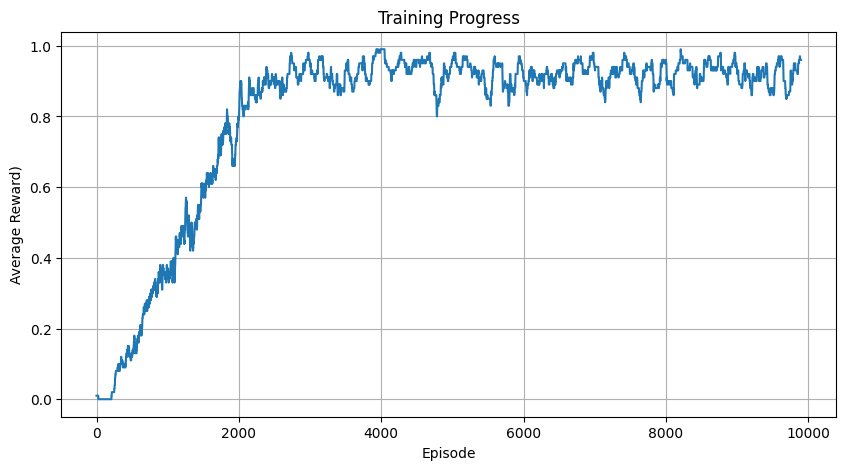

In [7]:
from utils import plot_rewards_curve
plot_rewards_curve(rewards_per_episode)

In [8]:
q_values

array([[0.16416802, 0.77378093, 0.163704  , 0.16565828],
       [0.16388259, 0.        , 0.12105225, 0.11765376],
       [0.21525766, 0.0391898 , 0.02659768, 0.10783872],
       [0.1307831 , 0.        , 0.0370145 , 0.06115432],
       [0.17333243, 0.81450625, 0.        , 0.22753722],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.75809927, 0.        , 0.12952072],
       [0.        , 0.        , 0.        , 0.        ],
       [0.68521236, 0.        , 0.857375  , 0.25156092],
       [0.25416678, 0.17998586, 0.9025    , 0.        ],
       [0.28550096, 0.95      , 0.        , 0.17966922],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.69742088, 0.94999865, 0.69344503],
       [0.90243129, 0.86961258, 1.        , 0.87196542],
       [0.        , 0.        , 0.        , 0.        ]])

# 测试

In [9]:
env = gym.make("FrozenLake-v1", render_mode="human", is_slippery=False)
state, _ = env.reset()
gain = 0
i = 0
import time
while True:
    i += 1
    action = q_values[state].argmax()
    state, reward, done, _, _ = env.step(action)
    env.render()
    time.sleep(1)
    gain += reward
    if done:
        break
print("total return: ", gain)

total return:  1


# 可视化动作价值

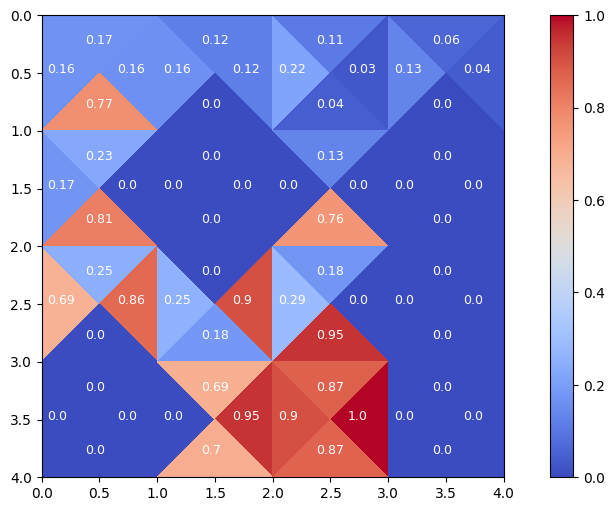

In [10]:
from utils import plot_action_value
plot_action_value(q_values)

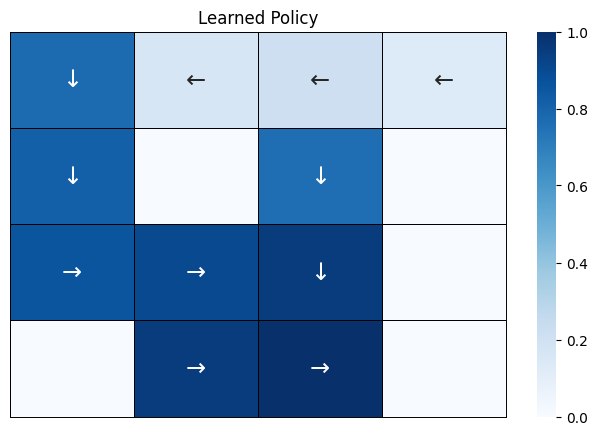

In [11]:
# 可视化动作策略
from utils import plot_policy_map
env = gym.make("FrozenLake-v1", render_mode="rgb_array", is_slippery=False)
env.reset()
plot_policy_map(q_values, env)